In [36]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
FILES_DIR = "."   # same folder as the notebook

NEWS_FILE = os.path.join(FILES_DIR, "news_data.json")
VIDEOS_FILE = os.path.join(FILES_DIR, "youtube_food_inflation_germany_videos.json")
COMMENTS_FILE = os.path.join(FILES_DIR, "youtube_food_inflation_comments_germany.json")

START_DATE = "2023-01-01"
END_DATE = "2026-12-31"

MIN_LENGTH_COMMENT = 5
MIN_LENGTH_TEXT = 5

In [38]:
print("Current working directory:")
print(os.getcwd())
print()

print("Files in current directory:")
print(os.listdir())
print()

print("Expected file paths:")
print(NEWS_FILE)
print(VIDEOS_FILE)
print(COMMENTS_FILE)

Current working directory:
/Users/rayyan/Desktop/arxiv_tutorial

Files in current directory:
['news_data.json', '.DS_Store', 'youtube_food_inflation_germany_videos.json', 'Untitled.ipynb', 'gdelt_API.json', 'fred_cpi_germany.json', 'Question7.ipynb', 'Question7_New.ipynb', 'Pipfile', '.ipynb_checkpoints', 'youtube_food_inflation_comments_germany.json', 'arxiv_tutorial', 'Pipfile.lock', 'Question8_New.ipynb']

Expected file paths:
./news_data.json
./youtube_food_inflation_germany_videos.json
./youtube_food_inflation_comments_germany.json


In [39]:
def load_news_json(filepath):
    """
    Load News API JSON and extract the articles list.
    Also handles files that start with 'news api:'.
    """
    with open(filepath, "r", encoding="utf-8-sig") as file:
        content = file.read().strip()

    if content.lower().startswith("news api:"):
        content = content[len("news api:"):].strip()

    raw_data = json.loads(content)

    if isinstance(raw_data, dict) and "articles" in raw_data:
        dataframe = pd.DataFrame(raw_data["articles"])
        return dataframe

    if isinstance(raw_data, list):
        dataframe = pd.DataFrame(raw_data)
        return dataframe

    raise ValueError("Unsupported structure in news_data.json")


def load_videos_json(filepath):
    """
    Load YouTube video JSON.
    """
    with open(filepath, "r", encoding="utf-8-sig") as file:
        raw_data = json.load(file)

    dataframe = pd.DataFrame(raw_data)
    return dataframe


def load_comments_json(filepath):
    """
    Load YouTube comments JSON.
    """
    with open(filepath, "r", encoding="utf-8-sig") as file:
        raw_data = json.load(file)

    dataframe = pd.DataFrame(raw_data, columns=["comment"])
    return dataframe

In [40]:
def clean_news_data(dataframe):
    """
    Clean news article data.
    """
    cleaned = dataframe.copy()

    useful_columns = ["title", "description", "publishedAt", "content"]
    available_columns = [column for column in useful_columns if column in cleaned.columns]
    cleaned = cleaned[available_columns].copy()

    cleaned["title"] = cleaned["title"].astype(str).str.strip()
    cleaned["description"] = cleaned["description"].fillna("").astype(str).str.strip()
    cleaned["content"] = cleaned["content"].fillna("").astype(str).str.strip()

    cleaned["publishedAt"] = pd.to_datetime(cleaned["publishedAt"], errors="coerce", utc=True)

    cleaned = cleaned.dropna(subset=["title", "publishedAt"])
    cleaned = cleaned[cleaned["title"].str.len() >= MIN_LENGTH_TEXT]
    cleaned = cleaned.drop_duplicates(subset=["title", "publishedAt"])
    cleaned = cleaned.sort_values("publishedAt").reset_index(drop=True)

    cleaned = cleaned[
        (cleaned["publishedAt"] >= START_DATE) &
        (cleaned["publishedAt"] <= END_DATE)
    ].copy()

    return cleaned


def clean_videos_data(dataframe):
    """
    Clean YouTube video data.
    """
    cleaned = dataframe.copy()

    useful_columns = ["video_id", "title", "description", "channel", "published_at"]
    available_columns = [column for column in useful_columns if column in cleaned.columns]
    cleaned = cleaned[available_columns].copy()

    cleaned["title"] = cleaned["title"].astype(str).str.strip()
    cleaned["description"] = cleaned["description"].fillna("").astype(str).str.strip()
    cleaned["channel"] = cleaned["channel"].fillna("").astype(str).str.strip()

    cleaned["published_at"] = pd.to_datetime(cleaned["published_at"], errors="coerce", utc=True)

    cleaned = cleaned.dropna(subset=["title", "published_at"])
    cleaned = cleaned[cleaned["title"].str.len() >= MIN_LENGTH_TEXT]
    cleaned = cleaned.drop_duplicates(subset=["video_id"])
    cleaned = cleaned.sort_values("published_at").reset_index(drop=True)

    cleaned = cleaned[
        (cleaned["published_at"] >= START_DATE) &
        (cleaned["published_at"] <= END_DATE)
    ].copy()

    return cleaned


def clean_comments_data(dataframe):
    """
    Clean comment data.
    """
    cleaned = dataframe.copy()

    cleaned["comment"] = cleaned["comment"].astype(str).str.strip()

    cleaned = cleaned.dropna(subset=["comment"])
    cleaned = cleaned[cleaned["comment"].str.len() >= MIN_LENGTH_COMMENT]
    cleaned = cleaned.drop_duplicates(subset=["comment"])
    cleaned = cleaned.reset_index(drop=True)

    return cleaned

In [41]:
def add_news_features(dataframe):
    """
    Add time variables and combined text field to news data.
    """
    result = dataframe.copy()

    result["publishedAt"] = result["publishedAt"].dt.tz_localize(None)
    result["year"] = result["publishedAt"].dt.year
    result["month_number"] = result["publishedAt"].dt.month
    result["month"] = result["publishedAt"].dt.to_period("M").dt.to_timestamp()

    result["text"] = (
        result["title"].fillna("") + " " +
        result["description"].fillna("") + " " +
        result["content"].fillna("")
    ).str.lower()

    result["platform"] = "news"

    return result


def add_video_features(dataframe):
    """
    Add time variables and combined text field to video data.
    """
    result = dataframe.copy()

    result["published_at"] = result["published_at"].dt.tz_localize(None)
    result["year"] = result["published_at"].dt.year
    result["month_number"] = result["published_at"].dt.month
    result["month"] = result["published_at"].dt.to_period("M").dt.to_timestamp()

    result["text"] = (
        result["title"].fillna("") + " " +
        result["description"].fillna("")
    ).str.lower()

    result["platform"] = "youtube_videos"

    return result


def add_comment_features(dataframe):
    """
    Add text field and platform label to comments.
    """
    result = dataframe.copy()

    result["text"] = result["comment"].fillna("").str.lower()
    result["platform"] = "youtube_comments"

    return result

In [42]:
def assign_narrative(text):
    """
    Assign one narrative category using simple keyword rules.
    """
    text = str(text).lower()

    corporate_greed_keywords = [
        "gier", "profit", "profite", "monopol", "abzocke", "abzock",
        "rekordgewinne", "konzerne", "margen", "supermarktketten",
        "handelsketten", "unternehmen"
    ]

    political_failure_keywords = [
        "politik", "regierung", "ampel", "cdu", "spd", "grüne",
        "bundesregierung", "staat", "fehlpolitik", "minister", "parteien"
    ]

    monetary_causes_keywords = [
        "ezb", "geldmenge", "gelddruck", "zinsen", "währung",
        "euro", "kaufkraft", "leitzins", "geldpolitik", "inflation"
    ]

    energy_tax_costs_keywords = [
        "co2", "co2-steuer", "energiepreise", "gas", "strom",
        "transport", "dünger", "sanktionen", "steuer", "kosten"
    ]

    if any(keyword in text for keyword in corporate_greed_keywords):
        return "corporate_greed"

    if any(keyword in text for keyword in political_failure_keywords):
        return "political_failure"

    if any(keyword in text for keyword in monetary_causes_keywords):
        return "monetary_causes"

    if any(keyword in text for keyword in energy_tax_costs_keywords):
        return "energy_tax_costs"

    return "other"


def classify_narratives(dataframe, text_column="text"):
    """
    Assign a narrative label to each row.
    """
    result = dataframe.copy()
    result["narrative"] = result[text_column].apply(assign_narrative)

    return result

In [43]:
news_raw = load_news_json(NEWS_FILE)
videos_raw = load_videos_json(VIDEOS_FILE)
comments_raw = load_comments_json(COMMENTS_FILE)

print("News raw shape:", news_raw.shape)
print("Videos raw shape:", videos_raw.shape)
print("Comments raw shape:", comments_raw.shape)

News raw shape: (58, 8)
Videos raw shape: (50, 5)
Comments raw shape: (541, 1)


In [44]:
news_clean = clean_news_data(news_raw)
videos_clean = clean_videos_data(videos_raw)
comments_clean = clean_comments_data(comments_raw)

print("News cleaned shape:", news_clean.shape)
print("Videos cleaned shape:", videos_clean.shape)
print("Comments cleaned shape:", comments_clean.shape)

News cleaned shape: (53, 4)
Videos cleaned shape: (49, 5)
Comments cleaned shape: (539, 1)


In [45]:
news_features = add_news_features(news_clean)
videos_features = add_video_features(videos_clean)
comments_features = add_comment_features(comments_clean)

news_classified = classify_narratives(news_features)
videos_classified = classify_narratives(videos_features)
comments_classified = classify_narratives(comments_features)

print("News classified shape:", news_classified.shape)
print("Videos classified shape:", videos_classified.shape)
print("Comments classified shape:", comments_classified.shape)

News classified shape: (53, 10)
Videos classified shape: (49, 11)
Comments classified shape: (539, 4)


In [46]:
news_narrative_counts = (
    news_classified.groupby("narrative", as_index=False)
    .agg(count=("title", "count"))
)
news_narrative_counts["platform"] = "news"

videos_narrative_counts = (
    videos_classified.groupby("narrative", as_index=False)
    .agg(count=("video_id", "count"))
)
videos_narrative_counts["platform"] = "youtube_videos"

comments_narrative_counts = (
    comments_classified.groupby("narrative", as_index=False)
    .agg(count=("comment", "count"))
)
comments_narrative_counts["platform"] = "youtube_comments"

combined_counts = pd.concat(
    [news_narrative_counts, videos_narrative_counts, comments_narrative_counts],
    ignore_index=True
)

combined_counts

,narrative,count,platform
0,corporate_greed,10,news
1,energy_tax_costs,1,news
2,monetary_causes,27,news
3,other,7,news
4,political_failure,8,news
5,corporate_greed,6,youtube_videos
6,energy_tax_costs,5,youtube_videos
7,monetary_causes,19,youtube_videos
8,other,15,youtube_videos
9,political_failure,4,youtube_videos


In [58]:
news_yearly = (
    news_classified.groupby(["year", "narrative"], as_index=False)
    .agg(count=("title", "count"))
)
news_yearly["platform"] = "news"


videos_yearly = (
    videos_classified.groupby(["year", "narrative"], as_index=False)
    .agg(count=("video_id", "count"))
)
videos_yearly["platform"] = "youtube_videos"


media_yearly = pd.concat(
    [news_yearly, videos_yearly],
    ignore_index=True
)

media_yearly.head()

,year,narrative,count,platform
0,2026,corporate_greed,10,news
1,2026,energy_tax_costs,1,news
2,2026,monetary_causes,27,news
3,2026,other,7,news
4,2026,political_failure,8,news


In [48]:
summary_table = combined_counts.pivot_table(
    index="narrative",
    columns="platform",
    values="count",
    aggfunc="sum",
    fill_value=0
)

summary_table

platform,news,youtube_comments,youtube_videos
narrative,,,
corporate_greed,10,51,6
energy_tax_costs,1,35,5
monetary_causes,27,57,19
other,7,336,15
political_failure,8,60,4


In [49]:
sns.set_theme(style="whitegrid")

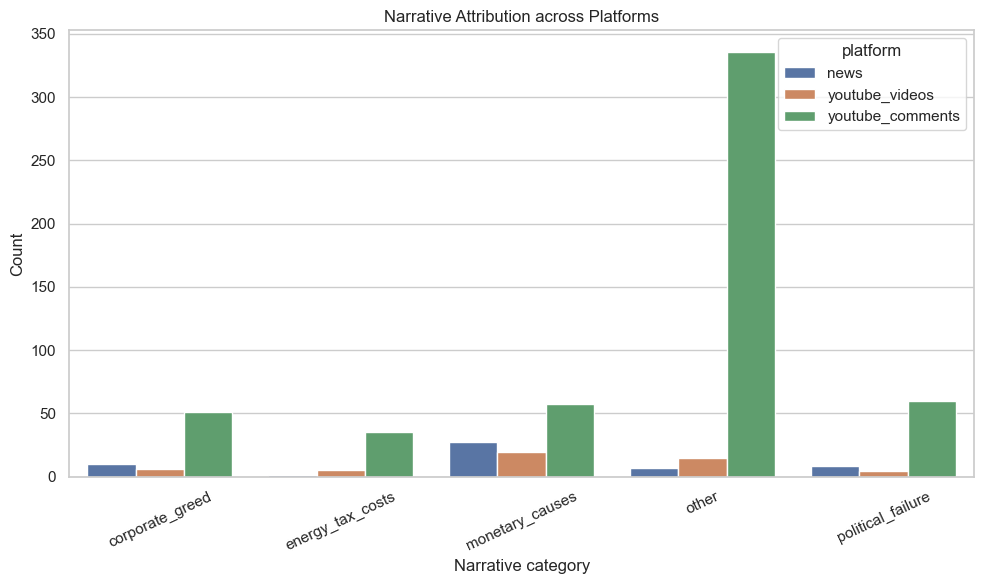

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=combined_counts,
    x="narrative",
    y="count",
    hue="platform"
)

plt.title("Narrative Attribution across Platforms")
plt.xlabel("Narrative category")
plt.ylabel("Count")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

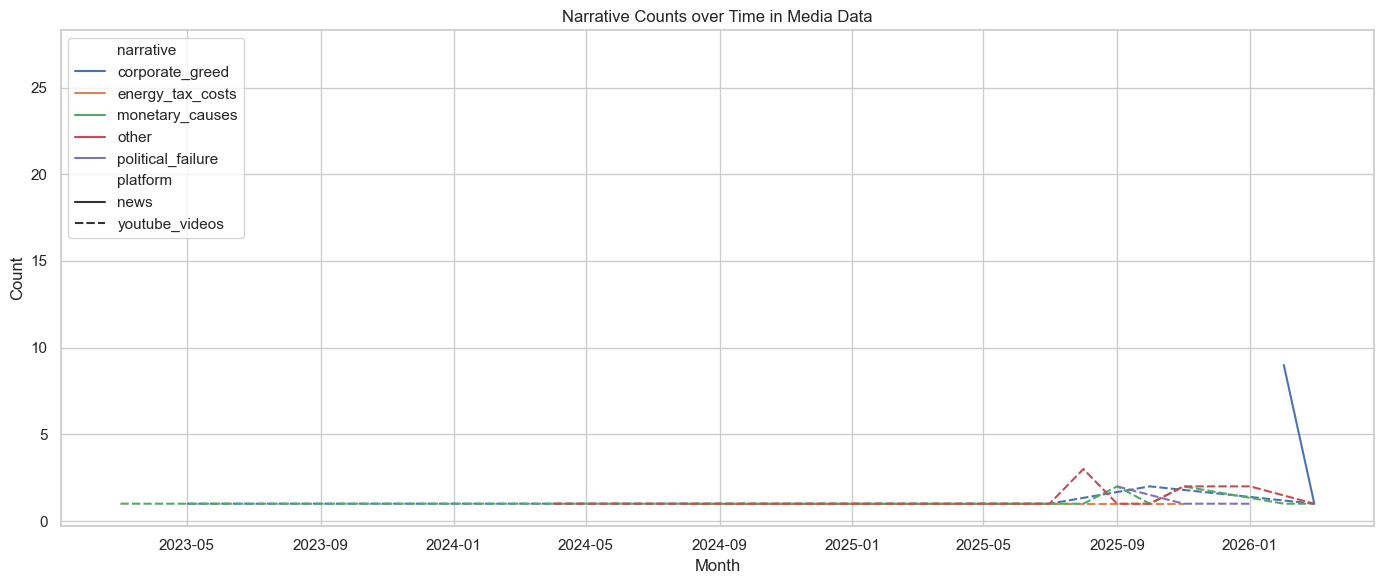

In [57]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=media_monthly,
    x="month",
    y="count",
    hue="narrative",
    style="platform"
)

plt.title("Narrative Counts over Time in Media Data")
plt.xlabel("Month")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

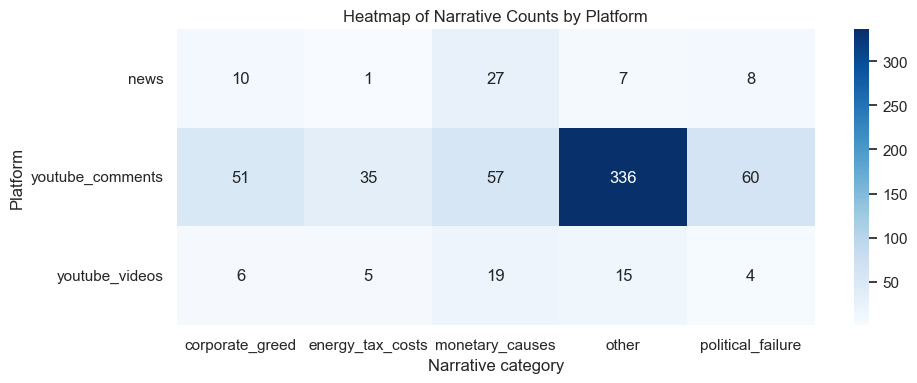

In [61]:
heatmap_df = combined_counts.pivot_table(
    index="platform",
    columns="narrative",
    values="count",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(10, 4))

sns.heatmap(heatmap_df, annot=True, fmt=".0f", cmap="Blues")

plt.title("Heatmap of Narrative Counts by Platform")
plt.xlabel("Narrative category")
plt.ylabel("Platform")
plt.tight_layout()
plt.show()

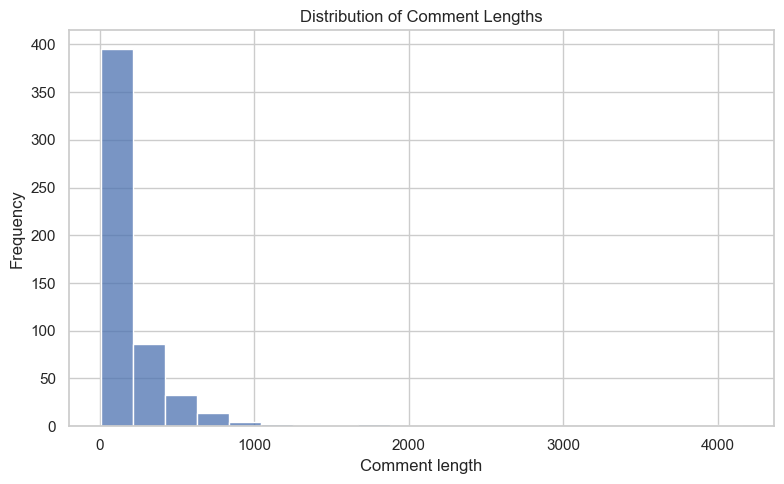

In [53]:
comments_features["comment_length"] = comments_features["comment"].str.len()

plt.figure(figsize=(8, 5))

sns.histplot(data=comments_features, x="comment_length", bins=20)

plt.title("Distribution of Comment Lengths")
plt.xlabel("Comment length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

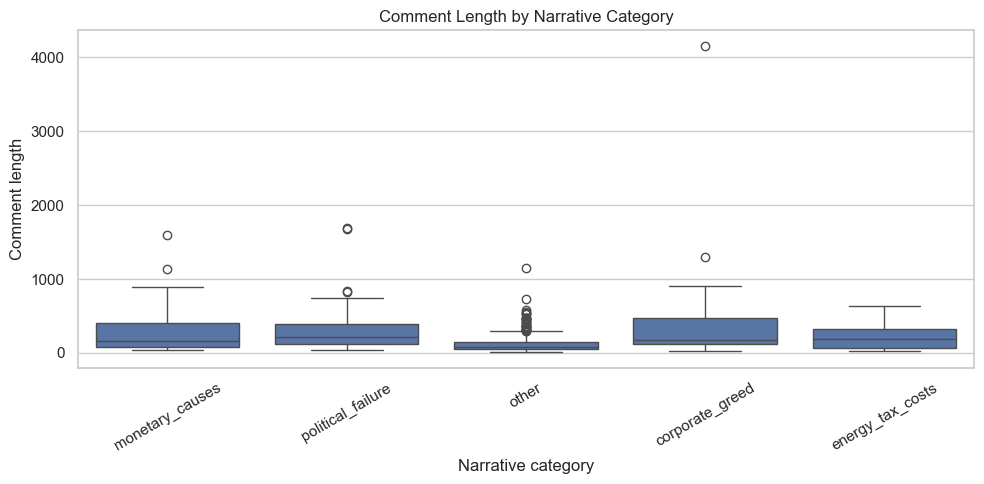

In [54]:
comments_classified["comment_length"] = comments_classified["comment"].str.len()

plt.figure(figsize=(10, 5))

sns.boxplot(data=comments_classified, x="narrative", y="comment_length")

plt.title("Comment Length by Narrative Category")
plt.xlabel("Narrative category")
plt.ylabel("Comment length")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

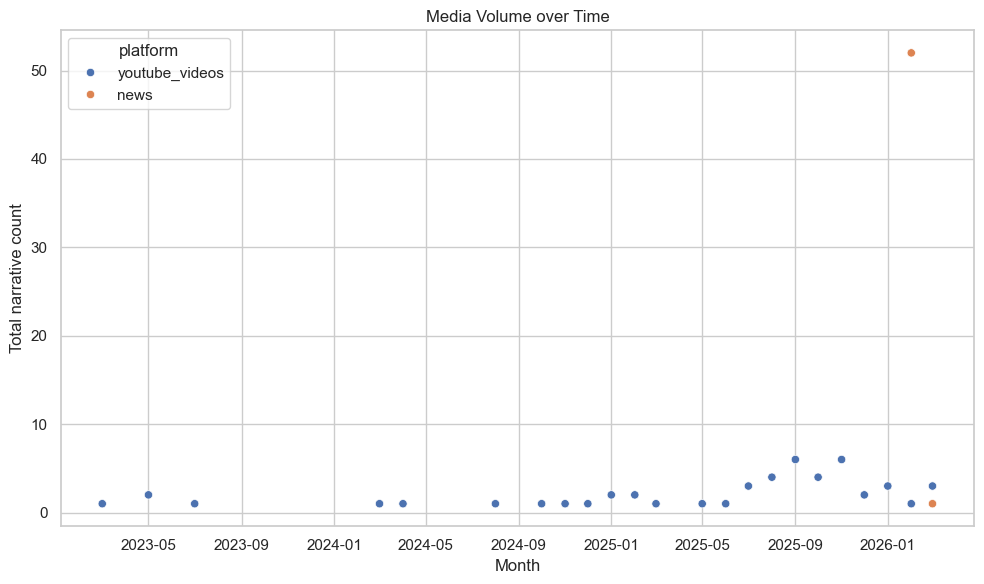

In [55]:
media_scatter = (
    media_monthly.groupby(["month", "platform"], as_index=False)
    .agg(total_count=("count", "sum"))
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=media_scatter,
    x="month",
    y="total_count",
    hue="platform"
)

plt.title("Media Volume over Time")
plt.xlabel("Month")
plt.ylabel("Total narrative count")
plt.tight_layout()
plt.show()

In [63]:
print("Top narrative in news:")
print(news_narrative_counts.sort_values("count", ascending=False).head(1))
print()

print("Top narrative in YouTube videos:")
print(videos_narrative_counts.sort_values("count", ascending=False).head(1))
print()

print("Top narrative in YouTube comments:")
print(comments_narrative_counts.sort_values("count", ascending=False).head(1))

Top narrative in news:
         narrative  count platform
2  monetary_causes     27     news

Top narrative in YouTube videos:
         narrative  count        platform
2  monetary_causes     19  youtube_videos

Top narrative in YouTube comments:
  narrative  count          platform
3     other    336  youtube_comments
